# 06 — Treinamento: o loop que faz o modelo aprender

> Destilado do paper TucanoCE, §7 (*Treinamento*).
> Objetivo: montar o loop de pré-treino completo — não só `loss.backward()`, mas
> tudo que separa um treino que converge de um que diverge ou desperdiça compute.

Nos notebooks 01–04 construímos a arquitetura; no 05, os dados. Aqui juntamos:
um modelo de brinquedo recebe um corpus tokenizado de brinquedo e **aprende**,
com cada peça de engenharia de treino que o paper usa na RTX 5070.

**O que você vai sair sabendo:**
1. O objetivo de treino (cross-entropy autoregressiva) e o truque do *label shift*.
2. Por que AdamW separa os parâmetros em dois grupos de *weight decay*.
3. Como o *scheduler* cosseno-com-warmup molda o learning rate ao longo do treino.
4. O que BF16, *gradient clipping*, *accumulation* e *early stopping* resolvem.
5. Ver todas as peças fiadas num loop que roda e faz a *loss* cair.

> Este notebook é a base direta do stub `src/tucanoce/training/train.py`.

In [1]:
import math
import tempfile
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
print("torch", torch.__version__, "| device: cpu (exemplos de brinquedo)")

torch 2.12.1+cpu | device: cpu (exemplos de brinquedo)


## 0. Um modelo e um corpus de brinquedo

O foco aqui é o **loop**, não a arquitetura — então montamos um transformer
minúsculo (2 blocos, d=32) inline. É a mesma espinha do notebook 03 (pre-norm,
atenção causal via `scaled_dot_product_attention`, MLP GELU, *weight tying*),
comprimida. Se algo aqui parecer novo, ele está explicado no nb 03.

In [2]:
class Block(nn.Module):
    # Bloco pre-norm compacto (ver nb 03 para a versão comentada).
    def __init__(self, d, n_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3 * d, bias=False)
        self.out = nn.Linear(d, d, bias=False)
        self.ln2 = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
        self.n_heads, self.head_dim = n_heads, d // n_heads

    def forward(self, x):
        B, T, D = x.shape
        q, k, v = self.qkv(self.ln1(x)).chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        a = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        x = x + self.out(a.transpose(1, 2).reshape(B, T, D))
        x = x + self.mlp(self.ln2(x))
        return x


class TinyGPT(nn.Module):
    def __init__(self, vocab, d=32, ctx=8, n_layers=2, n_heads=4):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(ctx, d)
        self.blocks = nn.ModuleList([Block(d, n_heads) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        self.head.weight = self.tok.weight          # weight tying
        self._init_weights()                        # init GPT-2 (0.02) -> loss inicial ~ ln(V)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Embedding)):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)
                if getattr(m, "bias", None) is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device)
        h = self.tok(x) + self.pos(pos)[None]
        for b in self.blocks:
            h = b(h)
        return self.head(self.ln_f(h))              # logits (B, T, vocab)


VOCAB, CTX = 16, 8
model = TinyGPT(VOCAB, ctx=CTX)
n_params = sum(p.numel() for p in model.parameters()) - model.head.weight.numel()
print(f"TinyGPT: {n_params:,} parâmetros (descontando weight tying)")

TinyGPT: 25,472 parâmetros (descontando weight tying)


In [3]:
# Corpus de brinquedo: sequências de tokens ALEATÓRIOS.
# Escolha deliberada: sem estrutura aprendível, o modelo só consegue MEMORIZAR o
# train. Isso produz um overfit limpo (train loss despenca, val loss não) — o
# cenário perfeito para o early stopping atuar mais adiante.
g = torch.Generator().manual_seed(42)

def make_batch(n_seq):
    data = torch.randint(0, VOCAB, (n_seq, CTX + 1), generator=g)
    return data[:, :-1].contiguous(), data[:, 1:].contiguous()   # (x, y): y = x shift 1

train_x, train_y = make_batch(12)   # pequeno de propósito -> memorizável
val_x,   val_y   = make_batch(8)    # não visto no treino
print("train x:", tuple(train_x.shape), "| val x:", tuple(val_x.shape))
print("y é x deslocado por 1 (próximo token):")
print("  x[0]:", train_x[0].tolist())
print("  y[0]:", train_y[0].tolist())

train x: (12, 8) | val x: (8, 8)
y é x deslocado por 1 (próximo token):
  x[0]: [6, 3, 12, 14, 10, 7, 12, 4]
  y[0]: [3, 12, 14, 10, 7, 12, 4, 6]


## 1. Objetivo de treino: cross-entropy autoregressiva (§7.1)

Treinamos por **máxima verossimilhança**: para cada posição $t$, maximizar a
log-probabilidade do token verdadeiro $x_{t+1}$ dado o prefixo. Em forma de *loss*
(Eq. 57 do paper):

$$ \mathcal{L}(\theta) = -\frac{1}{BT}\sum_{b=1}^{B}\sum_{t=1}^{T}
   \log P_\theta\big(x^{(b)}_{t+1}\mid x^{(b)}_{1:t}\big) $$

Na prática é uma linha: `F.cross_entropy` sobre os *logits* achatados. O detalhe
que costuma confundir: **toda posição emite uma predição ao mesmo tempo** (por
isso a máscara causal existe — nb 01/03), então uma única sequência de $T$ tokens
vira $T$ exemplos de treino de uma vez. O *label* é só a entrada deslocada por 1.

In [4]:
logits = model(train_x)                       # (B, T, V)
B, T, V = logits.shape
loss = F.cross_entropy(logits.view(-1, V), train_y.view(-1))
print(f"logits {tuple(logits.shape)}  ->  view(-1,V) = {tuple(logits.view(-1,V).shape)}")
print(f"targets {tuple(train_y.shape)} -> view(-1)   = {tuple(train_y.view(-1).shape)}")
print(f"loss inicial: {loss.item():.4f} nats/token")
print(f"piso trivial (chute uniforme) = ln(V) = {math.log(V):.4f} nats/token")
# Sanidade: no início, sem treino, a loss deve rondar ln(V).

logits (12, 8, 16)  ->  view(-1,V) = (96, 16)
targets (12, 8) -> view(-1)   = (96,)
loss inicial: 2.8021 nats/token
piso trivial (chute uniforme) = ln(V) = 2.7726 nats/token


O piso `ln(V)` é a *loss* de um modelo que não aprendeu nada (distribuição
uniforme sobre o vocabulário). É a primeira checagem de sanidade de qualquer
treino de LM: se a *loss* inicial não está perto de `ln(V)`, algo está errado na
inicialização ou no cálculo da *loss*. (No nb 07 exploramos essa métrica a fundo:
*bits per token*, BPC.)

## 2. AdamW com weight decay separado (§7.2)

Usamos **AdamW** (`lr` pico $3\cdot10^{-4}$, $\beta=(0.9, 0.999)$). A decisão
não-óbvia é separar os parâmetros em **dois grupos**:

- **Matrizes** (pesos 2D de `Linear`/embeddings): *weight decay* = 0.1.
- **Vetores 1D** (*biases*, `weight`/`bias` de normalização): *weight decay* = 0.

Por quê: o `weight decay` empurra pesos para zero, o que faz sentido para matrizes
(regularização). Mas o $\gamma$ de uma normalização controla diretamente a
**escala** que entra na próxima camada — penalizá-lo para zero distorce esse
equilíbrio em vez de regularizar. Mesma lógica para *biases*. A regra prática:
**decaia tensores 2D+, deixe 1D livres.**

In [5]:
def build_param_groups(model, weight_decay=0.1):
    # Separa params 2D+ (com decay) de 1D (sem decay). Paper §7.2.
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (decay if p.dim() >= 2 else no_decay).append(p)   # tied weight aparece 1x só
    return [
        {"params": decay,    "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ]

groups = build_param_groups(model, weight_decay=0.1)
n_decay = sum(p.numel() for p in groups[0]["params"])
n_nodec = sum(p.numel() for p in groups[1]["params"])
print(f"grupo COM decay  (2D+): {len(groups[0]['params']):2d} tensores, {n_decay:,} params")
print(f"grupo SEM decay  (1D) : {len(groups[1]['params']):2d} tensores, {n_nodec:,} params")

optimizer = torch.optim.AdamW(groups, lr=3e-4, betas=(0.9, 0.999), eps=1e-8)
print("otimizador:", type(optimizer).__name__, "| 2 grupos de weight_decay")

grupo COM decay  (2D+): 10 tensores, 25,344 params
grupo SEM decay  (1D) : 14 tensores, 640 params


otimizador: AdamW | 2 grupos de weight_decay


## 3. Scheduler: cosseno com warmup linear (§7.3)

O learning rate não é constante. Ele:

1. **Sobe linearmente** durante o *warmup* (primeiros $T_w = \min(T/10, 2000)$
   passos) — evita passos destrutivos no início, quando os gradientes são grandes
   e ruidosos.
2. **Desce por cosseno** até $\eta_{\min} = 0.1\,\eta_{\max}$ — decaimento suave
   que a comunidade converge como bom default.

$$ \eta(t) = \begin{cases}
   \eta_{\max}\cdot \dfrac{t}{T_w}, & t < T_w \\[2ex]
   \eta_{\min} + (\eta_{\max}-\eta_{\min})\cdot \dfrac{1}{2}\Big(1+\cos\big(\pi\,\tfrac{t-T_w}{T-T_w}\big)\Big), & T_w \le t \le T
   \end{cases} $$

In [6]:
def make_lr_lambda(total_steps, warmup_cap=2000, min_ratio=0.1):
    warmup = min(total_steps // 10, warmup_cap)
    warmup = max(warmup, 1)
    def lr_lambda(step):                          # retorna MULTIPLICADOR de lr_max
        if step < warmup:
            return step / warmup
        prog = (step - warmup) / max(total_steps - warmup, 1)
        cosine = 0.5 * (1 + math.cos(math.pi * prog))
        return min_ratio + (1 - min_ratio) * cosine
    return lr_lambda

# Curva ilustrativa sobre 200 passos (warmup = 20, depois cosseno até 0.1).
demo = make_lr_lambda(total_steps=200)
lr_max = 3e-4
print("Curva de learning rate (warmup linear -> decaimento cosseno):\n")
for step in range(0, 201, 10):
    lr = lr_max * demo(step)
    bar = "#" * int(60 * demo(step))
    print(f"step {step:3d} | lr={lr:.2e} | {bar}")

Curva de learning rate (warmup linear -> decaimento cosseno):

step   0 | lr=0.00e+00 | 
step  10 | lr=1.50e-04 | ##############################
step  20 | lr=3.00e-04 | ############################################################
step  30 | lr=2.98e-04 | ###########################################################
step  40 | lr=2.92e-04 | ##########################################################
step  50 | lr=2.82e-04 | ########################################################
step  60 | lr=2.68e-04 | #####################################################
step  70 | lr=2.52e-04 | ##################################################
step  80 | lr=2.32e-04 | ##############################################
step  90 | lr=2.11e-04 | ##########################################
step 100 | lr=1.88e-04 | #####################################
step 110 | lr=1.65e-04 | #################################
step 120 | lr=1.42e-04 | ############################
step 130 | lr=1.19e-04 | ######################

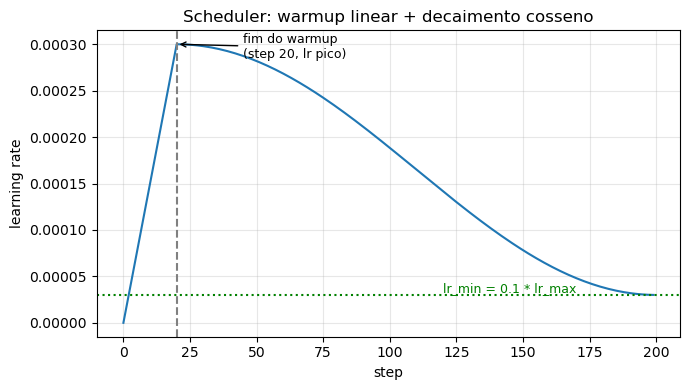

In [7]:
# A mesma curva, plotada — fica evidente o "pico" no fim do warmup e o decaimento cosseno.
import matplotlib.pyplot as plt

# Convenção visual do projeto (idêntica ao nb 00).
plt.rcParams.update({
    "figure.figsize": (6, 4), "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

total = 200
sched = make_lr_lambda(total_steps=total)
warmup = max(min(total // 10, 2000), 1)
xs = list(range(total))
ys = [lr_max * sched(s) for s in xs]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xs, ys, color="#1f77b4")
ax.axvline(warmup, ls="--", color="gray")
ax.annotate(f"fim do warmup\n(step {warmup}, lr pico)", xy=(warmup, lr_max),
            xytext=(warmup + 25, lr_max * 0.95), arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.axhline(lr_max * 0.1, ls=":", color="green")
ax.text(total * 0.6, lr_max * 0.1 + 3e-6, "lr_min = 0.1 * lr_max", color="green", fontsize=9)
ax.set_xlabel("step"); ax.set_ylabel("learning rate")
ax.set_title("Scheduler: warmup linear + decaimento cosseno")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

Repare no formato: sobe rápido até o pico (fim do *warmup*), depois desce
suavemente. No PyTorch isso vira um `LambdaLR` que multiplica o `lr` base a cada
`scheduler.step()`.

## 4. Precisão mista BF16 (§7.4)

Na RTX 5070 (Blackwell) o treino roda sob `torch.autocast(dtype=bfloat16)`. BF16
mantém o **range dinâmico** do FP32 (8 bits de expoente) sacrificando mantissa
(7 bits vs 23). Para transformers o trade-off é bom: o range amplo evita
*overflow* de gradiente, e a precisão reduzida basta para os *matmuls*.

Diferença crucial vs FP16: BF16 **dispensa `GradScaler`** (o FP16 precisa dele
porque seu range estreito faz gradientes pequenos virarem zero). Pesos e estado do
otimizador permanecem em FP32 — *mixed precision* é a média ponderada dos dois.

In [8]:
# Detecção de hardware — na CPU deste notebook, BF16-autocast fica desligado;
# na RTX 5070 seria o caminho real. O padrão de código é idêntico.
device = "cuda" if torch.cuda.is_available() else "cpu"
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
print(f"device={device} | BF16 suportado? {use_bf16}")

# Padrão de uso (enabled=False na CPU -> roda FP32, mas a estrutura é a mesma):
with torch.autocast(device_type=device, dtype=torch.bfloat16, enabled=use_bf16):
    out = model(train_x)
    demo_loss = F.cross_entropy(out.view(-1, V), train_y.view(-1))
print(f"forward sob autocast OK | loss={demo_loss.item():.4f} | dtype logits={out.dtype}")
print("Sem GradScaler: com BF16, chamamos loss.backward() e optimizer.step() direto.")

device=cpu | BF16 suportado? False
forward sob autocast OK | loss=2.8021 | dtype logits=torch.float32
Sem GradScaler: com BF16, chamamos loss.backward() e optimizer.step() direto.


## 5. Gradient clipping e accumulation (§7.5)

**Clipping por norma global** (Eq. 59): antes do `optimizer.step()`, se a norma
total dos gradientes passa de 1.0, reescalamos tudo para norma 1.0.

$$ g \leftarrow g \cdot \min\!\Big(1,\ \frac{1}{\lVert g\rVert_2}\Big) $$

Evita *spikes* esporádicos que desestabilizariam o treino sob *lr* alto. É um
seguro barato — na prática a norma fica quase sempre abaixo de 1.

**Gradient accumulation**: rodar $N$ *forwards/backwards* antes de um único
`optimizer.step()` dá um *batch* efetivo $B\cdot N$ **sem** custo de VRAM
proporcional. Útil quando o *batch* físico é limitado pela memória mas você quer
gradientes mais suaves. O truque: dividir a *loss* de cada micro-batch por $N$
(para a soma dos gradientes equivaler à média sobre o *batch* grande).

In [9]:
# Demonstração de UM passo com accumulation (N=2 micro-batches) + clipping.
accum_steps = 2
optimizer.zero_grad()
micro_x = train_x.chunk(accum_steps)
micro_y = train_y.chunk(accum_steps)
for mx, my in zip(micro_x, micro_y):
    logits = model(mx)
    loss = F.cross_entropy(logits.view(-1, V), my.view(-1)) / accum_steps  # escala por N
    loss.backward()                                                        # gradientes SOMAM

grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(f"norma global do gradiente ANTES do clip: {grad_norm:.4f}")
print(f"(clip ativa reescalando só se > 1.0)")
optimizer.step()
print("optimizer.step() aplicado sobre o batch efetivo B*N.")

norma global do gradiente ANTES do clip: 0.9932
(clip ativa reescalando só se > 1.0)
optimizer.step() aplicado sobre o batch efetivo B*N.


## 6. Early stopping com save-best (§7.6)

Rodar um número fixo de *epochs* desperdiça *compute* se o modelo já parou de
melhorar (ou começou a *overfitar*). Duas operações resolvem:

1. **Save-best**: a cada *epoch*, se `val_loss < best_val_loss`, sobrescreve o
   checkpoint. O melhor modelo visto fica sempre salvo — não o do último *epoch*.
2. **Patience-based stop**: conta *epochs* consecutivos sem melhora
   (`no_improve`). Se `no_improve >= patience`, encerra.

O paper reporta que no *medium* o melhor `val_loss` apareceu no *epoch* 8; os
*epochs* 9–12 só pioraram — o *early stopping* economizou ~18 min de *compute*.

## 7. Tudo junto: o loop de treino completo

Agora fiamos as seis peças. Como o corpus é aleatório (sem sinal aprendível),
esperamos o retrato clássico de **overfit**: a *train loss* despenca (o modelo
memoriza os 12 exemplos), enquanto a *val loss* trava perto de `ln(V)` e não
melhora — disparando o *early stopping* pouco depois do melhor *epoch*.

In [10]:
# --- setup do treino ---
torch.manual_seed(0)
model = TinyGPT(VOCAB, ctx=CTX)
MAX_EPOCHS, PATIENCE, ACCUM = 50, 4, 2
# lr bem acima dos 3e-4 do paper: com só 12 exemplos, isso acelera a memorização
# e torna o overfit (e o early stopping) visíveis em poucos epochs.
optimizer = torch.optim.AdamW(build_param_groups(model, 0.1),
                              lr=3e-3, betas=(0.9, 0.999), eps=1e-8)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, make_lr_lambda(total_steps=MAX_EPOCHS))

@torch.no_grad()
def eval_loss(x, y):
    model.eval()
    logits = model(x)
    return F.cross_entropy(logits.view(-1, V), y.view(-1)).item()

# --- estado do early stopping ---
best_val, no_improve, best_epoch = float("inf"), 0, -1
ckpt_path = tempfile.mktemp(suffix=".pt")
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    for mx, my in zip(train_x.chunk(ACCUM), train_y.chunk(ACCUM)):   # accumulation
        loss = F.cross_entropy(model(mx).view(-1, V), my.view(-1)) / ACCUM
        loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)          # clipping
    optimizer.step()
    scheduler.step()

    train_loss = eval_loss(train_x, train_y)
    val_loss = eval_loss(val_x, val_y)
    history.append((epoch, train_loss, val_loss))

    if val_loss < best_val - 1e-4:                                   # save-best
        best_val, best_epoch, no_improve = val_loss, epoch, 0
        torch.save(model.state_dict(), ckpt_path)
        tag = "  <- best (checkpoint salvo)"
    else:
        no_improve += 1
        tag = f"  (no_improve={no_improve})"

    if epoch <= 12 or no_improve >= PATIENCE:
        lr_now = scheduler.get_last_lr()[0]
        print(f"epoch {epoch:2d} | train {train_loss:.3f} | val {val_loss:.3f} "
              f"| lr {lr_now:.2e}{tag}")

    if no_improve >= PATIENCE:                                       # patience stop
        print(f"\n>> Early stopping no epoch {epoch}: "
              f"{PATIENCE} epochs sem melhora.")
        break

print(f"\nMelhor val_loss = {best_val:.3f} no epoch {best_epoch} "
      f"(checkpoint salvo é esse, não o do último epoch).")

epoch  1 | train 2.802 | val 2.778 | lr 6.00e-04  <- best (checkpoint salvo)
epoch  2 | train 2.760 | val 2.789 | lr 1.20e-03  (no_improve=1)
epoch  3 | train 2.696 | val 2.813 | lr 1.80e-03  (no_improve=2)
epoch  4 | train 2.640 | val 2.836 | lr 2.40e-03  (no_improve=3)
epoch  5 | train 2.586 | val 2.841 | lr 3.00e-03  (no_improve=4)

>> Early stopping no epoch 5: 4 epochs sem melhora.

Melhor val_loss = 2.778 no epoch 1 (checkpoint salvo é esse, não o do último epoch).


In [11]:
# Curva train vs val — a assinatura visual do overfit e do early stopping.
print("epoch | train  |  val   | gap (val-train)")
print("------+--------+--------+----------------")
for ep, tr, va in history:
    mark = " <-best" if ep == best_epoch else ""
    print(f" {ep:3d}  | {tr:.3f} | {va:.3f} | {va-tr:+.3f}{mark}")
print("\nLeitura: train despenca (memorização), val trava perto de ln(V) =",
      f"{math.log(V):.2f}. O gap crescente É o overfit; o early stopping corta o desperdício.")

epoch | train  |  val   | gap (val-train)
------+--------+--------+----------------
   1  | 2.802 | 2.778 | -0.025 <-best
   2  | 2.760 | 2.789 | +0.029
   3  | 2.696 | 2.813 | +0.116
   4  | 2.640 | 2.836 | +0.196
   5  | 2.586 | 2.841 | +0.255

Leitura: train despenca (memorização), val trava perto de ln(V) = 2.77. O gap crescente É o overfit; o early stopping corta o desperdício.


A mesma história, em figura — a **assinatura visual do overfit**. A `train loss`
despenca (o modelo memoriza os poucos exemplos), enquanto a `val loss` chega a um
mínimo e volta a subir. A linha verde marca o **melhor epoch** (o checkpoint que o
save-best guardou); a vermelha, onde o **early stopping** cortou o treino. Tudo à
direita da linha verde é compute que o early stopping nos poupou.

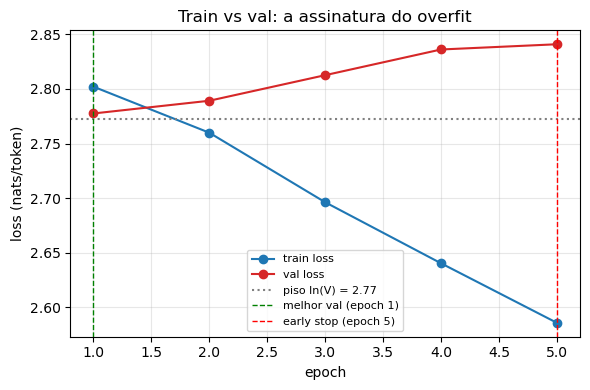

In [12]:
eps   = [ep for ep, _, _ in history]
trs   = [tr for _, tr, _ in history]
vas   = [va for _, _, va in history]

fig, ax = plt.subplots()
ax.plot(eps, trs, "o-", color="C0", label="train loss")
ax.plot(eps, vas, "o-", color="C3", label="val loss")
ax.axhline(math.log(V), ls=":", color="gray", label=f"piso ln(V) = {math.log(V):.2f}")
ax.axvline(best_epoch, color="green", ls="--", lw=1, label=f"melhor val (epoch {best_epoch})")
ax.axvline(eps[-1], color="red", ls="--", lw=1, label=f"early stop (epoch {eps[-1]})")
ax.set_xlabel("epoch"); ax.set_ylabel("loss (nats/token)")
ax.set_title("Train vs val: a assinatura do overfit")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Resumo (o que carregar para o notebook 07)

| Peça | Decisão | Por quê |
|---|---|---|
| Objetivo | cross-entropy autoregressiva | maximiza verossimilhança do próximo token; sanidade inicial ≈ ln(V) |
| AdamW | 2 grupos de weight decay (2D sim, 1D não) | não penalizar γ da norma / biases |
| Scheduler | warmup linear + cosseno até 0.1·lr_max | estabiliza início, decai suave |
| BF16 | autocast, sem GradScaler | range de FP32 com metade da memória |
| Grad clip | norma global = 1.0 | mata spikes sob lr alto |
| Accumulation | N micro-batches / step | batch efetivo maior sem VRAM extra |
| Early stopping | save-best + patience | salva o melhor modelo, corta compute desperdiçado |

**Ligação com o `src/`:** estas peças viram `build_param_groups()` e `train()` em
`src/tucanoce/training/train.py`. O loop acima é o esqueleto que você vai preencher.

**Caminho de evolução:** o paper aponta o otimizador **Muon** (Jordan et al., 2024)
como próximo passo — ortogonaliza gradientes de matrizes antes do passo AdamW e
treina mais rápido na mesma *compute* (ver *NanoGPT speedrun*).

Próximo: **`07_avaliacao_scaling.ipynb`** — cross-entropy → bits per char,
*sampling*, e o diagnóstico Chinchilla (o gargalo é dado, não capacidade).